# Data Reading and Visualization

**Working with Real Data in Python**

In this notebook, we'll learn how to read data from files and create visualizations. These are essential skills for any data science or machine learning project.

In [1]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 1.23.5
Pandas version: 1.4.4


## 1. Creating Sample Data

First, let's create some realistic sample datasets that we can work with.

In [2]:
# Create sample student performance dataset
np.random.seed(42)  # For reproducible results

n_students = 200

# Generate synthetic student data
student_data = {
    'student_id': range(1, n_students + 1),
    'study_hours': np.random.gamma(2, 2, n_students),  # Hours studied per week
    'previous_math_score': np.random.normal(75, 15, n_students),  # Previous math performance
    'attendance_rate': np.random.beta(8, 2, n_students),  # Attendance rate (0-1)
    'sleep_hours': np.random.normal(7, 1.5, n_students),  # Hours of sleep per night
    'extracurricular': np.random.choice([0, 1], n_students, p=[0.3, 0.7]),  # 0=No, 1=Yes
}

# Create exam score based on other factors (with some noise)
exam_score = (
    40 +  # Base score
    student_data['study_hours'] * 3 +  # Study hours effect
    student_data['previous_math_score'] * 0.3 +  # Previous performance
    student_data['attendance_rate'] * 20 +  # Attendance effect
    student_data['sleep_hours'] * 2 +  # Sleep effect
    student_data['extracurricular'] * 5 +  # Extracurricular bonus
    np.random.normal(0, 8, n_students)  # Random noise
)

# Clip scores to realistic range
exam_score = np.clip(exam_score, 0, 100)
student_data['exam_score'] = exam_score

# Clip other variables to realistic ranges
student_data['previous_math_score'] = np.clip(student_data['previous_math_score'], 0, 100)
student_data['sleep_hours'] = np.clip(student_data['sleep_hours'], 4, 12)
student_data['study_hours'] = np.clip(student_data['study_hours'], 0, 25)

# Convert to DataFrame
df = pd.DataFrame(student_data)

# Add categorical variables
df['major'] = np.random.choice(['Computer Science', 'Mathematics', 'Physics', 'Engineering'], 
                               n_students, p=[0.4, 0.2, 0.2, 0.2])
df['year'] = np.random.choice(['Freshman', 'Sophomore', 'Junior', 'Senior'], 
                              n_students, p=[0.3, 0.3, 0.25, 0.15])

print(f"Created dataset with {len(df)} students")
print(f"Columns: {list(df.columns)}")
df.head()

Created dataset with 200 students
Columns: ['student_id', 'study_hours', 'previous_math_score', 'attendance_rate', 'sleep_hours', 'extracurricular', 'exam_score', 'major', 'year']


,student_id,study_hours,previous_math_score,attendance_rate,sleep_hours,extracurricular,exam_score,major,year
0,1,4.787359,67.934425,0.760898,5.896705,1,100.000000,Engineering,Freshman
1,2,2.988929,78.480749,0.897137,8.854140,0,100.000000,Physics,Sophomore
2,3,2.764567,53.278735,0.842937,8.636965,1,99.831415,Physics,Freshman
3,4,2.764605,53.888043,0.878988,7.913707,1,100.000000,Computer Science,Sophomore
4,5,9.299429,64.223337,0.881890,5.361531,1,100.000000,Mathematics,Sophomore


## 2. Saving and Loading Data

### Saving Data to CSV

In [3]:
# Save to CSV file
df.to_csv('student_performance.csv', index=False)
print("Data saved to 'student_performance.csv'")

# Also create a simplified version for the in-class exercise
exercise_df = df[['student_id', 'study_hours', 'exam_score', 'major', 'year']].copy()
exercise_df.to_csv('class_exercise_data.csv', index=False)
print("Simplified data saved to 'class_exercise_data.csv'")

# Show what the CSV looks like
print("\nFirst few lines of the CSV file:")
with open('student_performance.csv', 'r') as f:
    for i, line in enumerate(f):
        if i < 5:  # Show first 5 lines
            print(line.strip())
        else:
            break

Data saved to 'student_performance.csv'
Simplified data saved to 'class_exercise_data.csv'

First few lines of the CSV file:
student_id,study_hours,previous_math_score,attendance_rate,sleep_hours,extracurricular,exam_score,major,year
1,4.787358779738473,67.93442541572516,0.7608977983341839,5.89670508611535,1,100.0,Engineering,Freshman
2,2.988929460431175,78.48074906036454,0.897137390965522,8.854139762815656,0,100.0,Physics,Sophomore
3,2.764567168741907,53.27873487754014,0.8429369126181151,8.636965180891403,1,99.83141541836285,Physics,Freshman
4,2.7646045886636013,53.888043384351676,0.8789880368915142,7.913707181360765,1,100.0,Computer Science,Sophomore


### Reading Data from CSV

In [4]:
# Read data back from CSV
df_loaded = pd.read_csv('student_performance.csv')

print(f"Loaded data shape: {df_loaded.shape}")
print(f"Data types:")
print(df_loaded.dtypes)
print("\nFirst 3 rows:")
df_loaded.head(3)

Loaded data shape: (200, 9)
Data types:
student_id               int64
study_hours            float64
previous_math_score    float64
attendance_rate        float64
sleep_hours            float64
extracurricular          int64
exam_score             float64
major                   object
year                    object
dtype: object

First 3 rows:


,student_id,study_hours,previous_math_score,attendance_rate,sleep_hours,extracurricular,exam_score,major,year
0,1,4.787359,67.934425,0.760898,5.896705,1,100.000000,Engineering,Freshman
1,2,2.988929,78.480749,0.897137,8.854140,0,100.000000,Physics,Sophomore
2,3,2.764567,53.278735,0.842937,8.636965,1,99.831415,Physics,Freshman


## 3. Data Exploration and Summary Statistics

### Basic Data Information

In [5]:
# Get basic info about the dataset
print("Dataset Information:")
print(f"Shape: {df_loaded.shape}")
print(f"Memory usage: {df_loaded.memory_usage().sum() / 1024:.1f} KB")

print("\nColumn information:")
df_loaded.info()

print("\nMissing values:")
print(df_loaded.isnull().sum())

Dataset Information:
Shape: (200, 9)
Memory usage: 14.2 KB

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           200 non-null    int64  
 1   study_hours          200 non-null    float64
 2   previous_math_score  200 non-null    float64
 3   attendance_rate      200 non-null    float64
 4   sleep_hours          200 non-null    float64
 5   extracurricular      200 non-null    int64  
 6   exam_score           200 non-null    float64
 7   major                200 non-null    object 
 8   year                 200 non-null    object 
dtypes: float64(5), int64(2), object(2)
memory usage: 14.2+ KB

Missing values:
student_id             0
study_hours            0
previous_math_score    0
attendance_rate        0
sleep_hours            0
extracurricular        0
exam_score             0
major      

### Summary Statistics

In [6]:
# Descriptive statistics for numerical columns
print("Descriptive Statistics:")
numerical_cols = df_loaded.select_dtypes(include=[np.number]).columns
print(df_loaded[numerical_cols].describe().round(2))

print("\nCategorical Variables:")
categorical_cols = df_loaded.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_loaded[col].value_counts())

Descriptive Statistics:
       student_id  study_hours  previous_math_score  attendance_rate  \
count      200.00       200.00               200.00           200.00   
mean       100.50         3.98                73.94             0.79   
std         57.88         2.55                14.48             0.12   
min          1.00         0.36                40.47             0.46   
25%         50.75         2.06                63.05             0.72   
50%        100.50         3.50                74.11             0.82   
75%        150.25         5.25                84.25             0.88   
max        200.00        14.60               100.00             0.99   

       sleep_hours  extracurricular  exam_score  
count       200.00           200.00      200.00  
mean          7.16             0.69       98.36  
std           1.45             0.46        4.15  
min           4.00             0.00       78.20  
25%           6.12             0.00      100.00  
50%           7.19         

## 4. Data Visualization

### Single Variable Plots

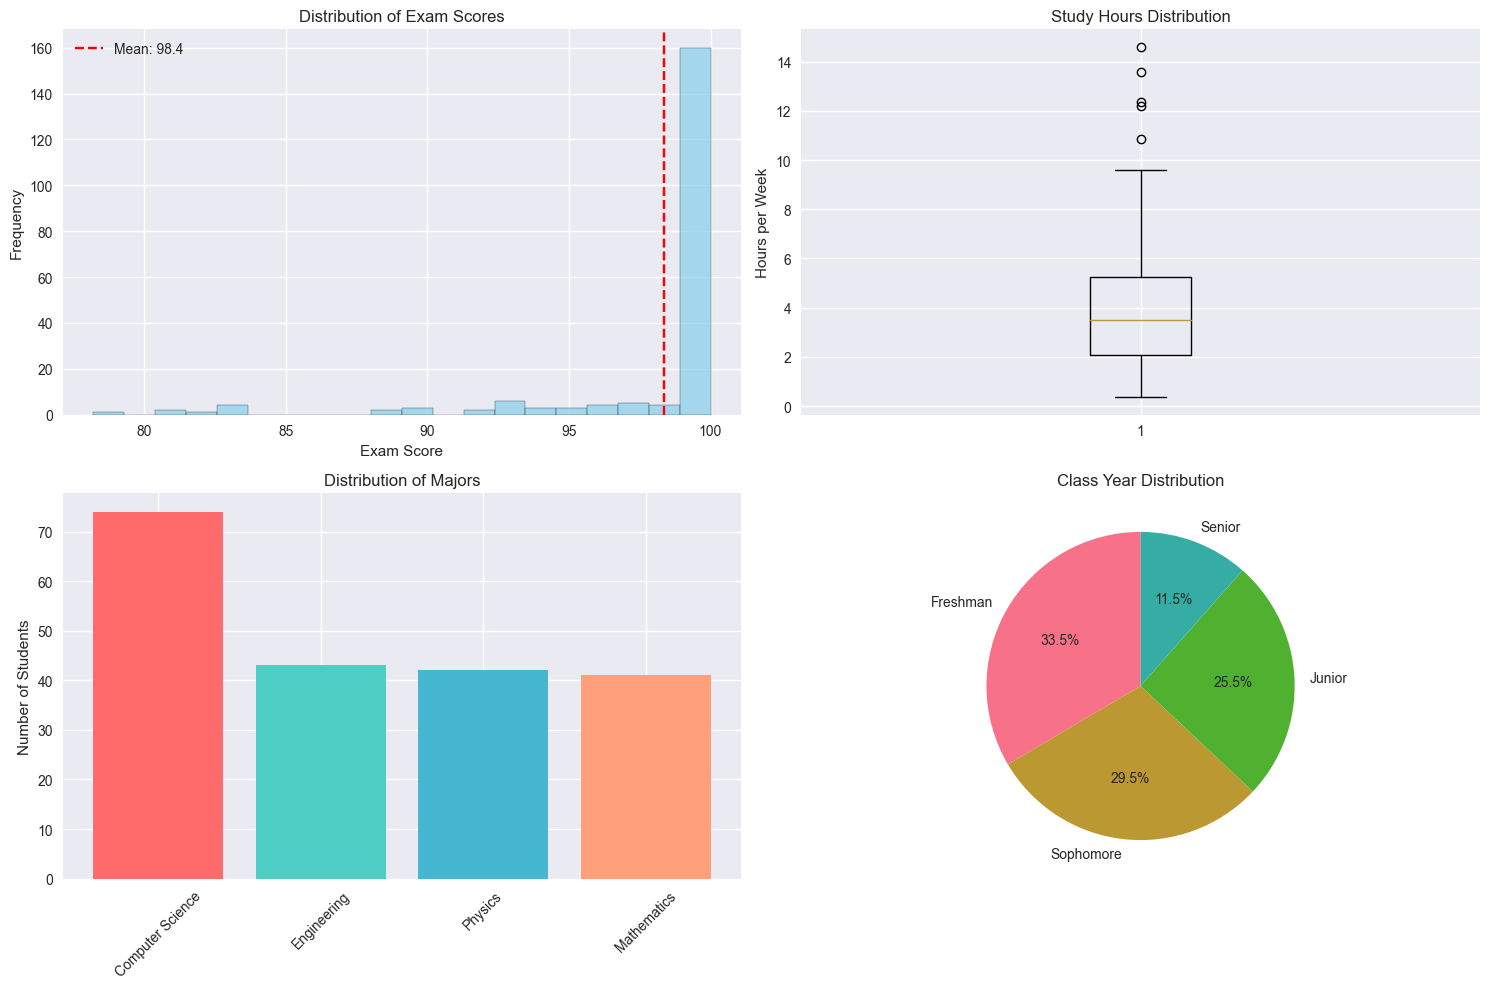

In [7]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram of exam scores
axes[0,0].hist(df_loaded['exam_score'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribution of Exam Scores')
axes[0,0].set_xlabel('Exam Score')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df_loaded['exam_score'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df_loaded["exam_score"].mean():.1f}')
axes[0,0].legend()

# Box plot of study hours
axes[0,1].boxplot(df_loaded['study_hours'])
axes[0,1].set_title('Study Hours Distribution')
axes[0,1].set_ylabel('Hours per Week')

# Bar plot of majors
major_counts = df_loaded['major'].value_counts()
axes[1,0].bar(major_counts.index, major_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[1,0].set_title('Distribution of Majors')
axes[1,0].set_ylabel('Number of Students')
axes[1,0].tick_params(axis='x', rotation=45)

# Pie chart of year distribution
year_counts = df_loaded['year'].value_counts()
axes[1,1].pie(year_counts.values, labels=year_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Class Year Distribution')

plt.tight_layout()
plt.show()

### Relationship Between Variables

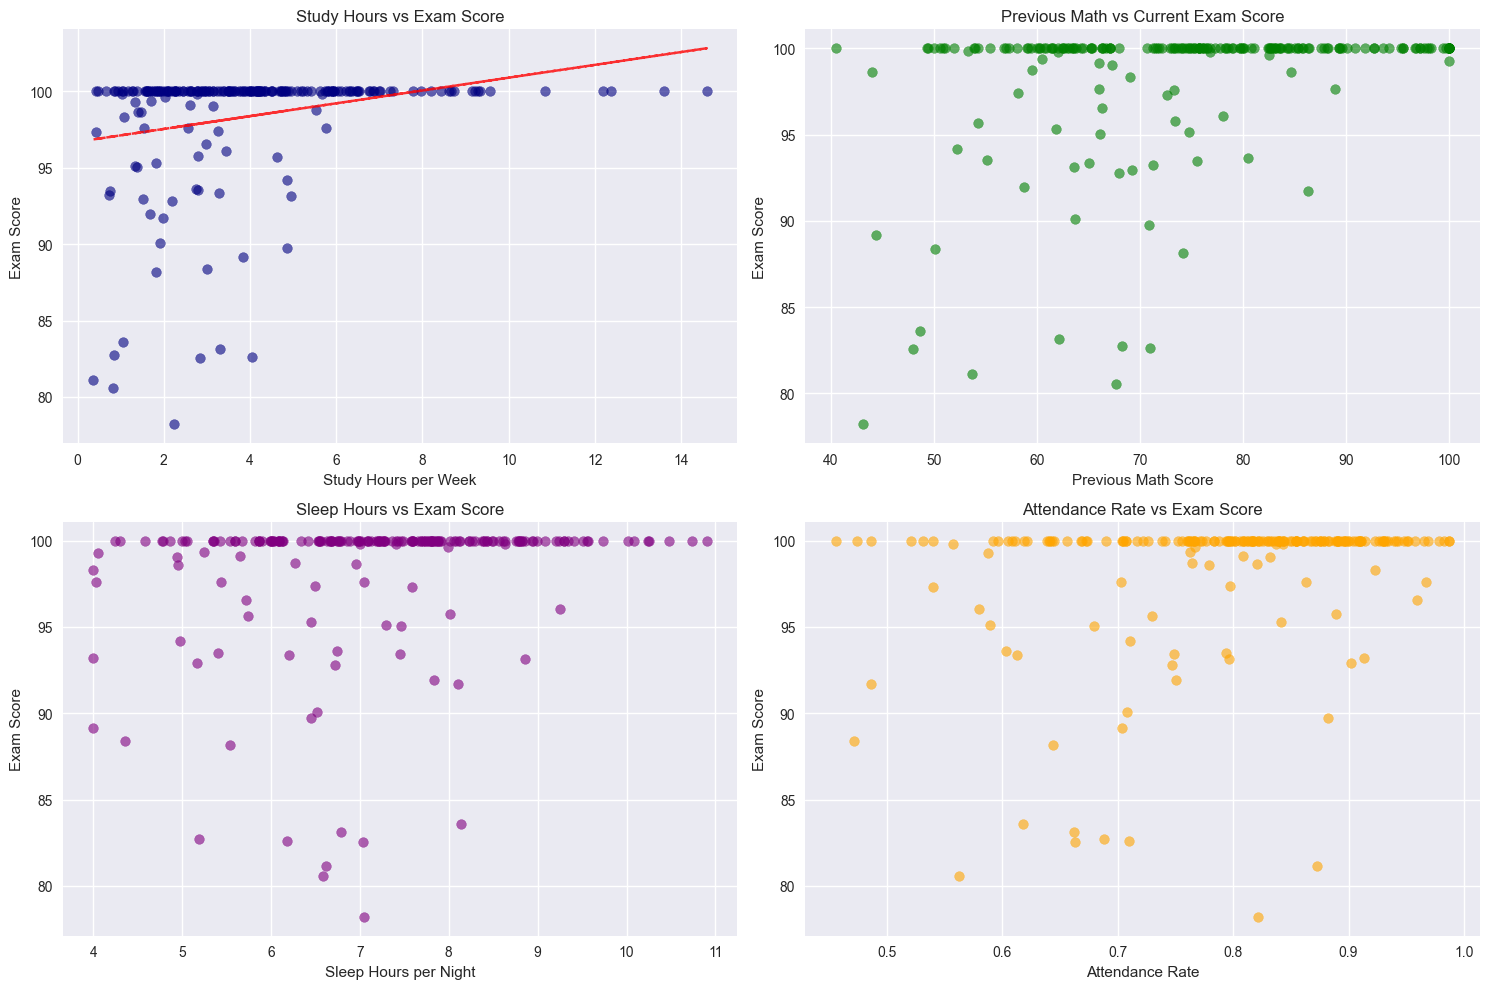

In [8]:
# Scatter plots to explore relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Study hours vs exam score
axes[0,0].scatter(df_loaded['study_hours'], df_loaded['exam_score'], alpha=0.6, color='navy')
axes[0,0].set_xlabel('Study Hours per Week')
axes[0,0].set_ylabel('Exam Score')
axes[0,0].set_title('Study Hours vs Exam Score')
# Add trend line
z = np.polyfit(df_loaded['study_hours'], df_loaded['exam_score'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_loaded['study_hours'], p(df_loaded['study_hours']), "r--", alpha=0.8)

# Previous math score vs exam score
axes[0,1].scatter(df_loaded['previous_math_score'], df_loaded['exam_score'], alpha=0.6, color='green')
axes[0,1].set_xlabel('Previous Math Score')
axes[0,1].set_ylabel('Exam Score')
axes[0,1].set_title('Previous Math vs Current Exam Score')

# Sleep hours vs exam score
axes[1,0].scatter(df_loaded['sleep_hours'], df_loaded['exam_score'], alpha=0.6, color='purple')
axes[1,0].set_xlabel('Sleep Hours per Night')
axes[1,0].set_ylabel('Exam Score')
axes[1,0].set_title('Sleep Hours vs Exam Score')

# Attendance rate vs exam score
axes[1,1].scatter(df_loaded['attendance_rate'], df_loaded['exam_score'], alpha=0.6, color='orange')
axes[1,1].set_xlabel('Attendance Rate')
axes[1,1].set_ylabel('Exam Score')
axes[1,1].set_title('Attendance Rate vs Exam Score')

plt.tight_layout()
plt.show()

### Advanced Visualizations with Seaborn

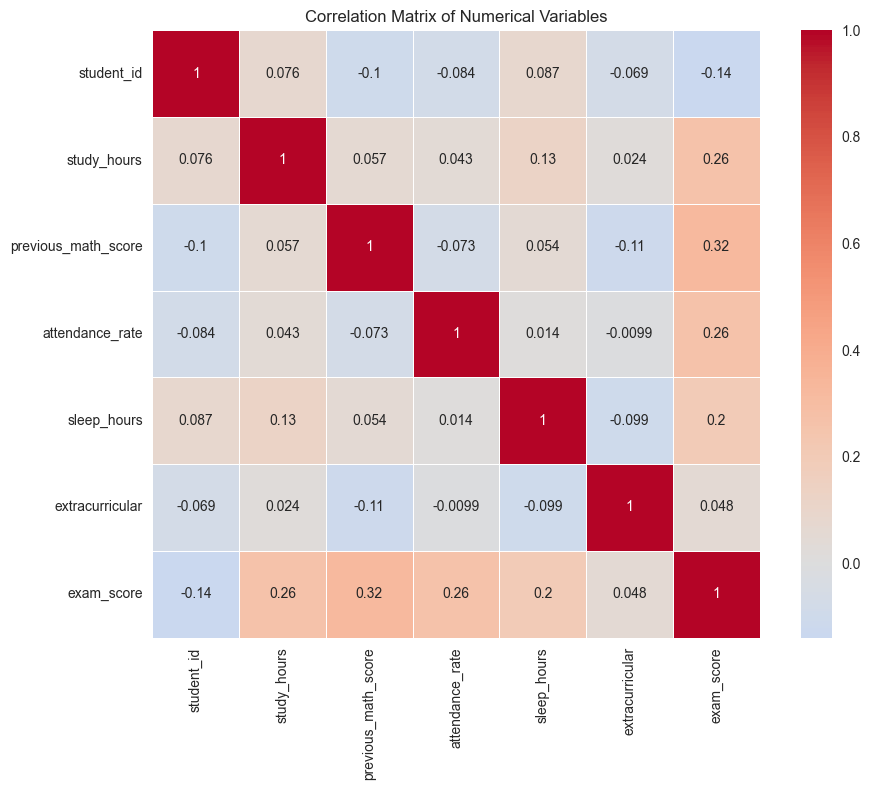

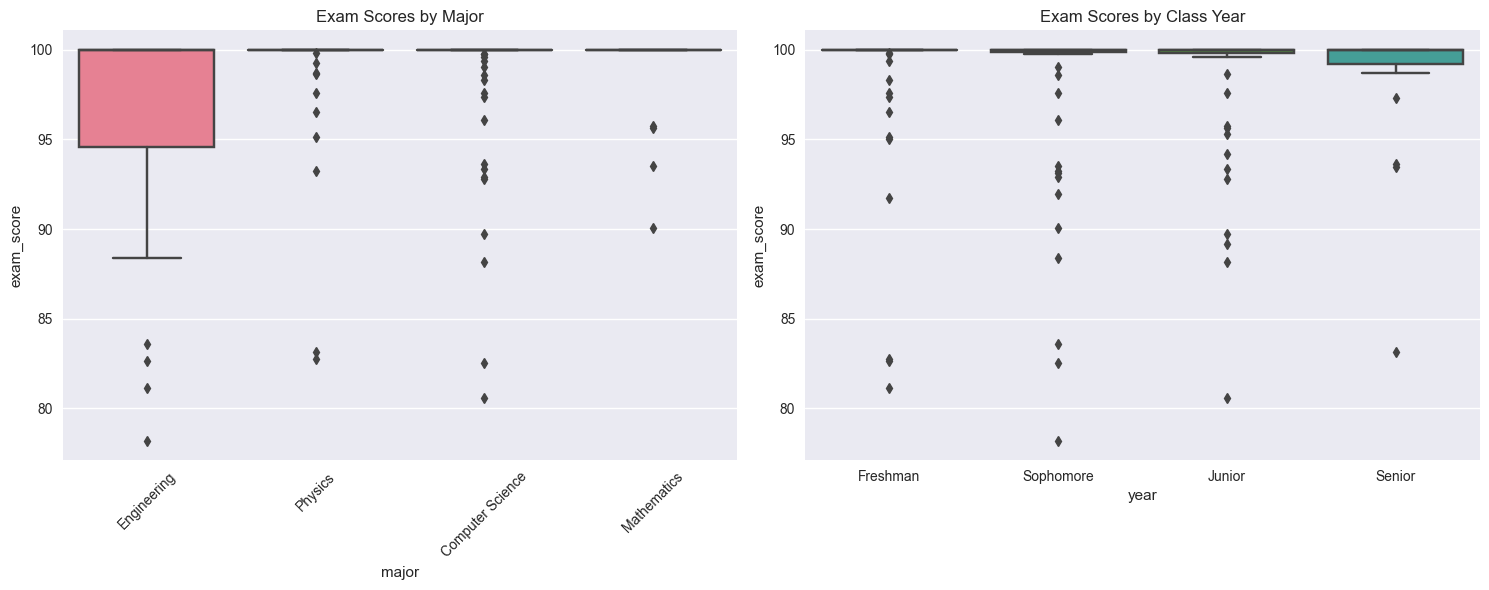

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df_loaded[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

# Box plots by category
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Exam scores by major
sns.boxplot(data=df_loaded, x='major', y='exam_score', ax=axes[0])
axes[0].set_title('Exam Scores by Major')
axes[0].tick_params(axis='x', rotation=45)

# Exam scores by year
sns.boxplot(data=df_loaded, x='year', y='exam_score', ax=axes[1])
axes[1].set_title('Exam Scores by Class Year')

plt.tight_layout()
plt.show()

### Pair Plots for Multiple Relationships

<Figure size 1200x1000 with 0 Axes>

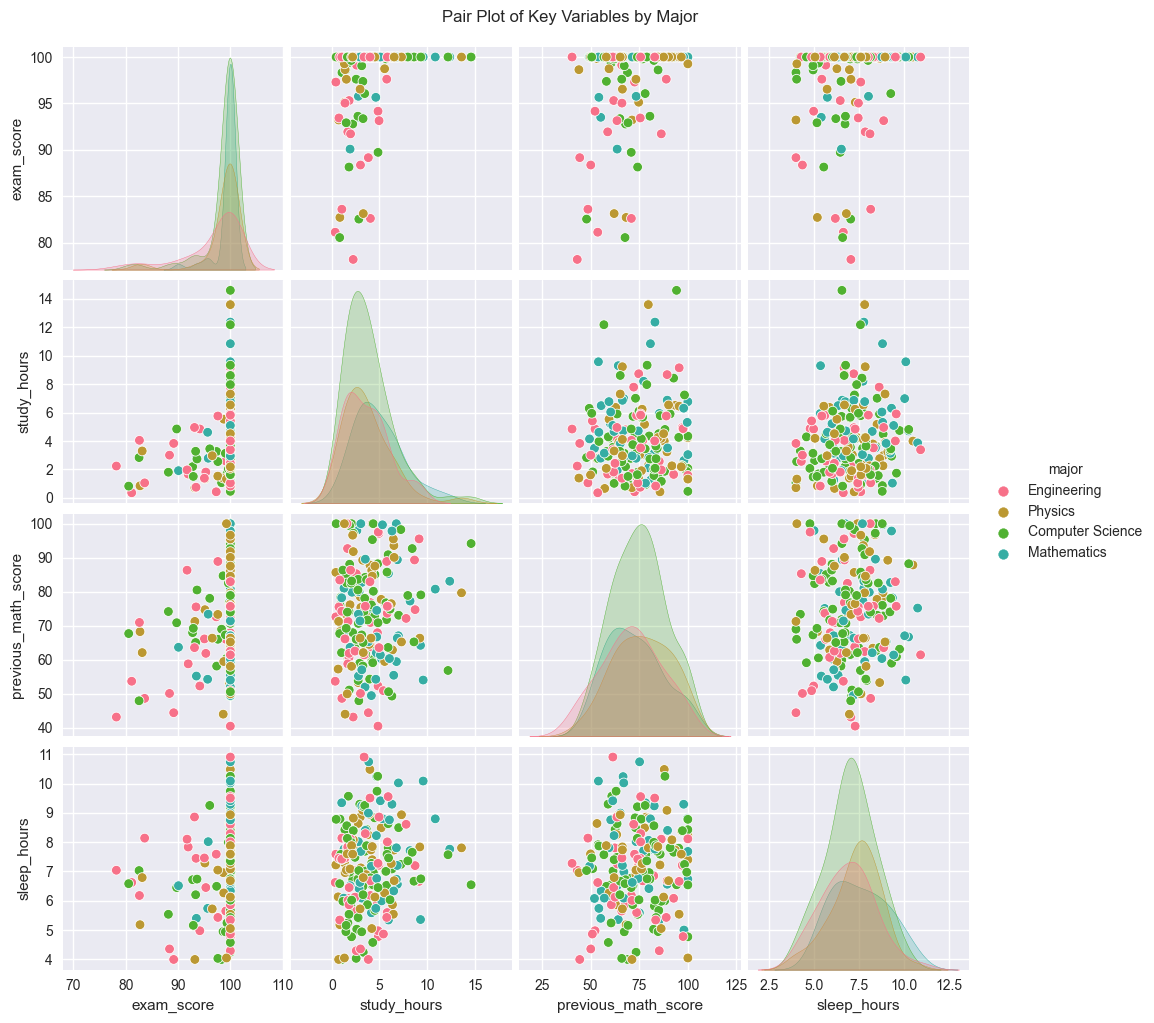

In [11]:
# Select a subset of variables for pair plot
subset_vars = ['exam_score', 'study_hours', 'previous_math_score', 'sleep_hours', 'major']
subset_df = df_loaded[subset_vars]

# Create pair plot
plt.figure(figsize=(12, 10))
pair_plot = sns.pairplot(subset_df, hue='major')
pair_plot.fig.suptitle('Pair Plot of Key Variables by Major', y=1.02)
plt.show()

## 5. Statistical Analysis

### Correlation Analysis

In [12]:
# Calculate correlations with exam score
correlations = df_loaded[numerical_cols].corr()['exam_score'].sort_values(key=abs, ascending=False)

print("Correlations with Exam Score:")
print("=" * 35)
for var, corr in correlations.items():
    if var != 'exam_score':
        print(f"{var:20s}: {corr:6.3f}")

# Statistical significance testing
print("\nStatistical Significance Tests:")
print("=" * 35)

# Correlation significance
for var in ['study_hours', 'previous_math_score', 'sleep_hours', 'attendance_rate']:
    correlation, p_value = stats.pearsonr(df_loaded[var], df_loaded['exam_score'])
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"{var:20s}: r={correlation:6.3f}, p={p_value:8.6f} {significance}")

print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05")

Correlations with Exam Score:
previous_math_score :  0.321
attendance_rate     :  0.261
study_hours         :  0.257
sleep_hours         :  0.200
student_id          : -0.139
extracurricular     :  0.048

Statistical Significance Tests:
study_hours         : r= 0.257, p=0.000235 ***
previous_math_score : r= 0.321, p=0.000004 ***
sleep_hours         : r= 0.200, p=0.004510 **
attendance_rate     : r= 0.261, p=0.000189 ***

Significance levels: *** p<0.001, ** p<0.01, * p<0.05


### Group Comparisons

In [13]:
# Compare exam scores between groups
print("Group Comparisons:")
print("=" * 30)

# Extracurricular activities
extra_yes = df_loaded[df_loaded['extracurricular'] == 1]['exam_score']
extra_no = df_loaded[df_loaded['extracurricular'] == 0]['exam_score']

t_stat, p_value = stats.ttest_ind(extra_yes, extra_no)
print(f"Extracurricular Activities:")
print(f"  With activities: {extra_yes.mean():.1f} ± {extra_yes.std():.1f}")
print(f"  Without activities: {extra_no.mean():.1f} ± {extra_no.std():.1f}")
print(f"  t-test: t={t_stat:.3f}, p={p_value:.6f}")

# Compare by major using ANOVA
major_groups = [df_loaded[df_loaded['major'] == major]['exam_score'] for major in df_loaded['major'].unique()]
f_stat, p_value = stats.f_oneway(*major_groups)

print(f"\nMajor Comparison (ANOVA):")
for major in df_loaded['major'].unique():
    major_scores = df_loaded[df_loaded['major'] == major]['exam_score']
    print(f"  {major:15s}: {major_scores.mean():.1f} ± {major_scores.std():.1f}")
print(f"  F-test: F={f_stat:.3f}, p={p_value:.6f}")

Group Comparisons:
Extracurricular Activities:
  With activities: 98.5 ± 4.2
  Without activities: 98.1 ± 4.2
  t-test: t=0.676, p=0.499896

Major Comparison (ANOVA):
  Engineering    : 96.6 ± 5.9
  Physics        : 98.7 ± 3.8
  Computer Science: 98.6 ± 3.7
  Mathematics    : 99.4 ± 2.0
  F-test: F=3.909, p=0.009672


## 6. Advanced Plotting Techniques

### Custom Styling and Annotations

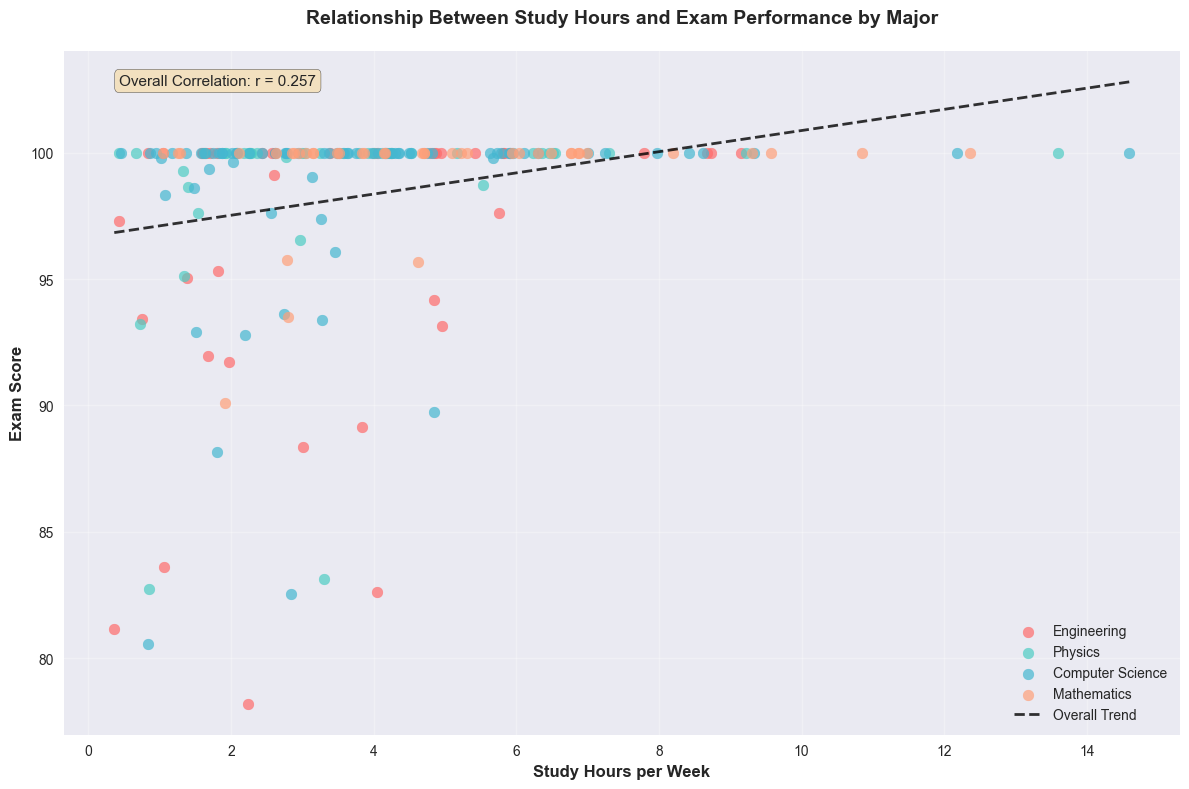

In [14]:
# Create a publication-quality plot
plt.figure(figsize=(12, 8))

# Create scatter plot with different colors for majors
majors = df_loaded['major'].unique()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for i, major in enumerate(majors):
    major_data = df_loaded[df_loaded['major'] == major]
    plt.scatter(major_data['study_hours'], major_data['exam_score'], 
               c=colors[i], label=major, alpha=0.7, s=60)

# Add overall trend line
z = np.polyfit(df_loaded['study_hours'], df_loaded['exam_score'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df_loaded['study_hours'].min(), df_loaded['study_hours'].max(), 100)
plt.plot(x_trend, p(x_trend), "k--", alpha=0.8, linewidth=2, label='Overall Trend')

# Customize the plot
plt.xlabel('Study Hours per Week', fontsize=12, fontweight='bold')
plt.ylabel('Exam Score', fontsize=12, fontweight='bold')
plt.title('Relationship Between Study Hours and Exam Performance by Major', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)

# Add text annotation
correlation = df_loaded['study_hours'].corr(df_loaded['exam_score'])
plt.text(0.05, 0.95, f'Overall Correlation: r = {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

### Interactive Elements and Subplots

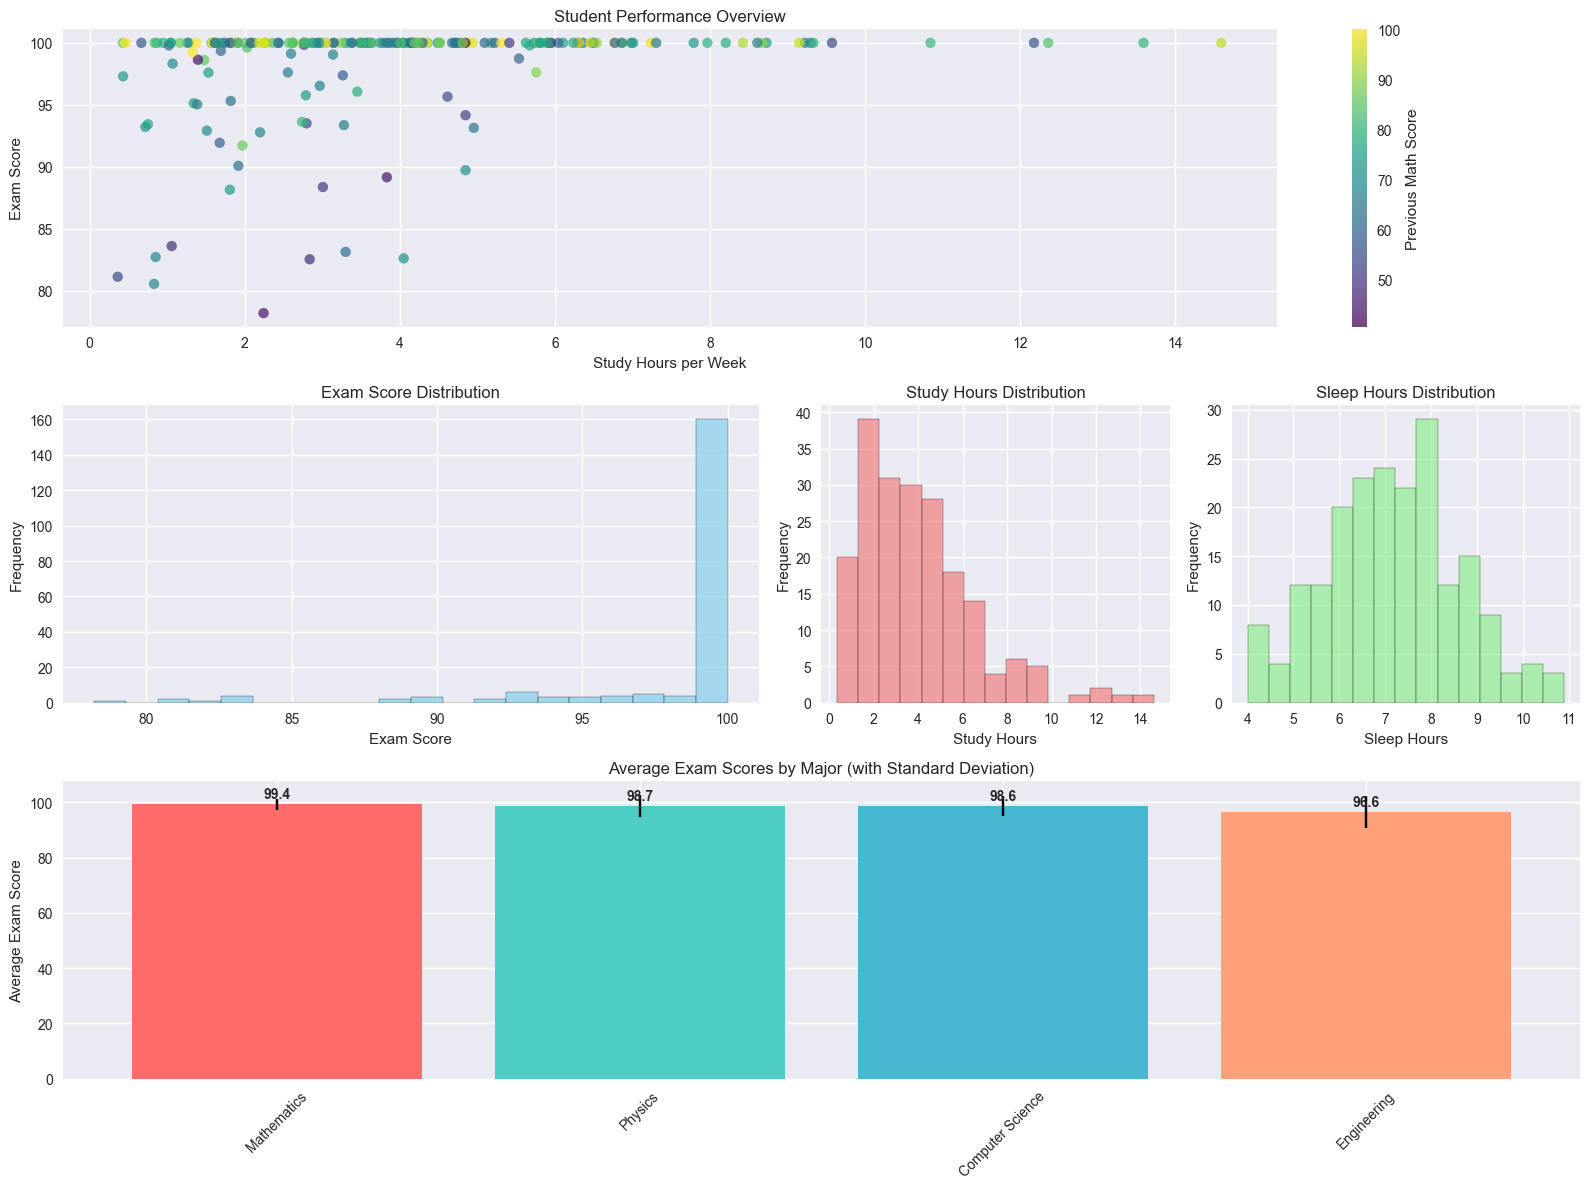

In [15]:
# Create a dashboard-style visualization
fig = plt.figure(figsize=(16, 12))

# Define grid layout
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1], width_ratios=[2, 1, 1])

# Main scatter plot
ax1 = fig.add_subplot(gs[0, :])
scatter = ax1.scatter(df_loaded['study_hours'], df_loaded['exam_score'], 
                     c=df_loaded['previous_math_score'], cmap='viridis', 
                     alpha=0.7, s=50)
ax1.set_xlabel('Study Hours per Week')
ax1.set_ylabel('Exam Score')
ax1.set_title('Student Performance Overview')
plt.colorbar(scatter, ax=ax1, label='Previous Math Score')

# Distribution plots
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(df_loaded['exam_score'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax2.set_xlabel('Exam Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Exam Score Distribution')

ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(df_loaded['study_hours'], bins=15, alpha=0.7, color='lightcoral', edgecolor='black')
ax3.set_xlabel('Study Hours')
ax3.set_ylabel('Frequency')
ax3.set_title('Study Hours Distribution')

ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(df_loaded['sleep_hours'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
ax4.set_xlabel('Sleep Hours')
ax4.set_ylabel('Frequency')
ax4.set_title('Sleep Hours Distribution')

# Categorical analysis
ax5 = fig.add_subplot(gs[2, :])
major_means = df_loaded.groupby('major')['exam_score'].mean().sort_values(ascending=False)
major_stds = df_loaded.groupby('major')['exam_score'].std()
bars = ax5.bar(major_means.index, major_means.values, 
               yerr=major_stds[major_means.index], capsize=5, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax5.set_ylabel('Average Exam Score')
ax5.set_title('Average Exam Scores by Major (with Standard Deviation)')
ax5.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, value in zip(bars, major_means.values):
    ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, 
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Data Export and Sharing

### Different File Formats

In [17]:
# Export data in different formats

# 1. CSV (most common)
df_loaded.to_csv('student_data_processed.csv', index=False)
print(" Saved as CSV")

# 2. Excel format
try:
    df_loaded.to_excel('student_data_processed.xlsx', index=False)
    print(" Saved as Excel")
except ImportError:
    print(" Excel export requires openpyxl: pip install openpyxl")

# 3. JSON format
df_loaded.to_json('student_data_processed.json', orient='records', indent=2)
print(" Saved as JSON")

# 4. Create a summary report
summary_stats = df_loaded.describe()
summary_stats.to_csv('summary_statistics.csv')
print(" Saved summary statistics")

# Show file sizes
import os
files = ['student_data_processed.csv', 'student_data_processed.json', 'summary_statistics.csv']
print("\nFile sizes:")
for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024  # Size in KB
        print(f"  {file}: {size:.1f} KB")

 Saved as CSV
 Saved as Excel
 Saved as JSON
 Saved summary statistics

File sizes:
  student_data_processed.csv: 21.2 KB
  student_data_processed.json: 52.9 KB
  summary_statistics.csv: 0.8 KB


### Save Plots

 Plots saved as PNG and PDF


<Figure size 1200x800 with 0 Axes>

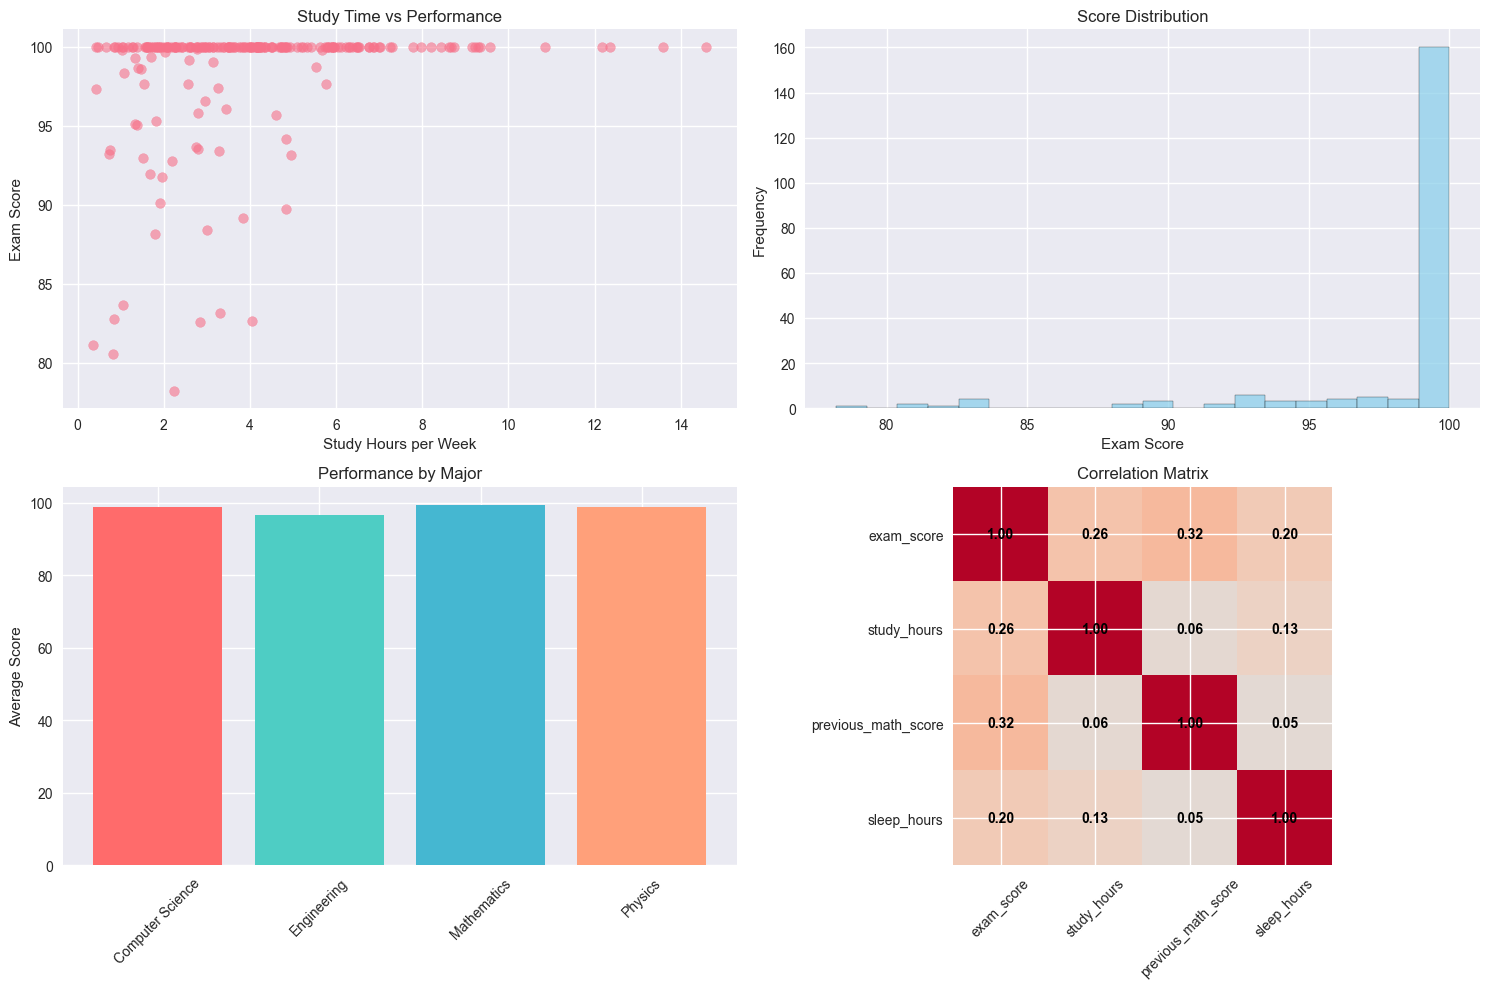

In [18]:
# Create and save a summary plot
plt.figure(figsize=(12, 8))

# Create subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Main relationship
ax1.scatter(df_loaded['study_hours'], df_loaded['exam_score'], alpha=0.6)
ax1.set_xlabel('Study Hours per Week')
ax1.set_ylabel('Exam Score')
ax1.set_title('Study Time vs Performance')

# Plot 2: Distribution
ax2.hist(df_loaded['exam_score'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax2.set_xlabel('Exam Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Score Distribution')

# Plot 3: Category comparison
major_means = df_loaded.groupby('major')['exam_score'].mean()
ax3.bar(major_means.index, major_means.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax3.set_ylabel('Average Score')
ax3.set_title('Performance by Major')
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Correlation heatmap
corr_subset = df_loaded[['exam_score', 'study_hours', 'previous_math_score', 'sleep_hours']].corr()
im = ax4.imshow(corr_subset, cmap='coolwarm', vmin=-1, vmax=1)
ax4.set_xticks(range(len(corr_subset.columns)))
ax4.set_yticks(range(len(corr_subset.columns)))
ax4.set_xticklabels(corr_subset.columns, rotation=45)
ax4.set_yticklabels(corr_subset.columns)
ax4.set_title('Correlation Matrix')

# Add correlation values
for i in range(len(corr_subset.columns)):
    for j in range(len(corr_subset.columns)):
        text = ax4.text(j, i, f'{corr_subset.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontweight='bold')

plt.tight_layout()

# Save the plot
plt.savefig('student_performance_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('student_performance_analysis.pdf', bbox_inches='tight')
print(" Plots saved as PNG and PDF")

plt.show()

## 8. Best Practices and Tips

### Data Quality Checks

In [19]:
def data_quality_report(df, name="Dataset"):
    """Generate a comprehensive data quality report"""
    print(f" Data Quality Report: {name}")
    print("=" * 50)
    
    # Basic info
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
    
    # Missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\n  Missing values found:")
        for col, count in missing[missing > 0].items():
            pct = count / len(df) * 100
            print(f"   {col}: {count} ({pct:.1f}%)")
    else:
        print("\n No missing values")
    
    # Duplicates
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"\n  {duplicates} duplicate rows found")
    else:
        print("\n No duplicate rows")
    
    # Data types
    print(f"\n Data types:")
    type_counts = df.dtypes.value_counts()
    for dtype, count in type_counts.items():
        print(f"   {dtype}: {count} columns")
    
    # Numerical columns outliers
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    if len(numerical_cols) > 0:
        print(f"\n Numerical columns summary:")
        for col in numerical_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
            print(f"   {col}: {outliers} potential outliers ({outliers/len(df)*100:.1f}%)")
    
    print("\n" + "=" * 50)

# Generate report for our dataset
data_quality_report(df_loaded, "Student Performance Dataset")

 Data Quality Report: Student Performance Dataset
Shape: 200 rows × 9 columns
Memory usage: 37.1 KB

 No missing values

 No duplicate rows

 Data types:
   float64: 5 columns
   int64: 2 columns
   object: 2 columns

 Numerical columns summary:
   student_id: 0 potential outliers (0.0%)
   study_hours: 5 potential outliers (2.5%)
   previous_math_score: 0 potential outliers (0.0%)
   attendance_rate: 1 potential outliers (0.5%)
   sleep_hours: 0 potential outliers (0.0%)
   extracurricular: 0 potential outliers (0.0%)
   exam_score: 49 potential outliers (24.5%)



### Plotting Best Practices

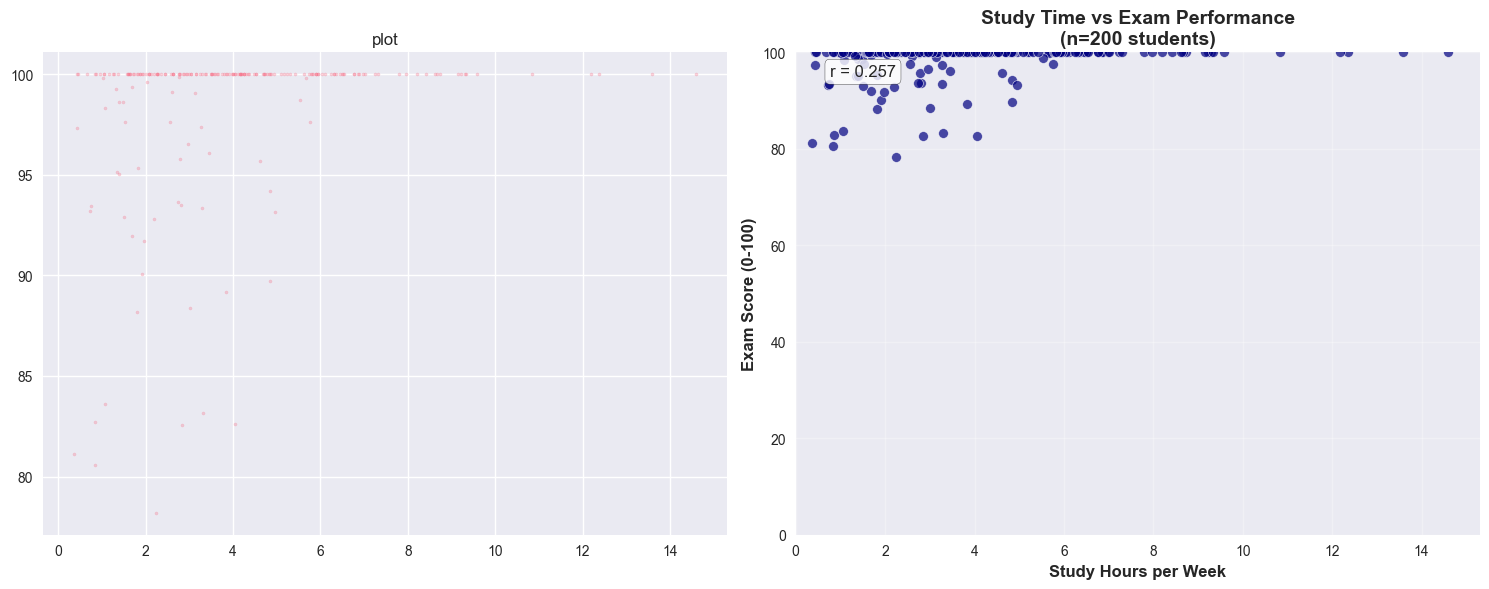

Key plotting principles:
 Clear, descriptive titles and axis labels
 Appropriate point size and transparency
 Include sample size and key statistics
 Use grids and appropriate axis limits
 Choose colors wisely (colorblind-friendly)
 Save in appropriate resolution for use case


In [20]:
# Demonstrate good vs bad plotting practices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bad plot - difficult to read
ax1.scatter(df_loaded['study_hours'], df_loaded['exam_score'], s=5, alpha=0.3)
ax1.set_title('plot')
# No axis labels, poor title, hard to see points

# Good plot - clear and informative
ax2.scatter(df_loaded['study_hours'], df_loaded['exam_score'], 
           alpha=0.7, s=50, color='navy', edgecolors='white', linewidth=0.5)
ax2.set_xlabel('Study Hours per Week', fontsize=12, fontweight='bold')
ax2.set_ylabel('Exam Score (0-100)', fontsize=12, fontweight='bold')
ax2.set_title('Study Time vs Exam Performance\n(n=200 students)', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, None)
ax2.set_ylim(0, 100)

# Add correlation info
corr = df_loaded['study_hours'].corr(df_loaded['exam_score'])
ax2.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax2.transAxes, 
         fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("Key plotting principles:")
print(" Clear, descriptive titles and axis labels")
print(" Appropriate point size and transparency")
print(" Include sample size and key statistics")
print(" Use grids and appropriate axis limits")
print(" Choose colors wisely (colorblind-friendly)")
print(" Save in appropriate resolution for use case")

## 9. Clean Up

Remove temporary files created during this session.

In [21]:
# Clean up files (optional - comment out if you want to keep them)
import os

files_to_remove = [
    'student_performance.csv',
    'student_data_processed.csv',
    'student_data_processed.json', 
    'summary_statistics.csv',
    'student_performance_analysis.png',
    'student_performance_analysis.pdf'
]

print("Files that could be cleaned up:")
for file in files_to_remove:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024
        print(f"  {file} ({size:.1f} KB)")
        # Uncomment next line to actually remove files
        # os.remove(file)
    else:
        print(f"  {file} (not found)")

print("\n Tip: Keep 'class_exercise_data.csv' for the in-class exercise!")

Files that could be cleaned up:
  student_performance.csv (21.3 KB)
  student_data_processed.csv (21.2 KB)
  student_data_processed.json (52.9 KB)
  summary_statistics.csv (0.8 KB)
  student_performance_analysis.png (431.8 KB)
  student_performance_analysis.pdf (27.2 KB)

 Tip: Keep 'class_exercise_data.csv' for the in-class exercise!


## Summary

In this notebook, you learned:

### Data Reading and Writing
- Loading data from CSV files with pandas
- Exploring data structure and basic statistics
- Saving data in multiple formats (CSV, JSON, Excel)

### Data Visualization
- Single variable plots (histograms, box plots, bar charts)
- Relationship plots (scatter plots, correlation heatmaps)
- Advanced visualizations with Seaborn
- Custom styling and professional-quality plots

### Statistical Analysis
- Correlation analysis and significance testing
- Group comparisons (t-tests, ANOVA)
- Data quality assessment

### Best Practices
- Data quality checks and validation
- Effective plotting principles
- File management and organization

## Next Steps

You're now ready to work with real data! In the in-class exercise, you'll apply these skills to explore a dataset and answer questions through data analysis and visualization.